# Конвейер данных: препроцессинг, аугментация и загрузка

Ноутбук определяет и верифицирует конвейер обработки данных для задачи сегментации
гиппокампа. Конвейер преобразует исходные NIfTI-файлы в форму, пригодную для подачи на
вход трёхмерной сегментационной модели, и формирует загрузчики обучающей и валидационной
подвыборок. Содержание следует структуре медицинского исследования: введению с
методологическим контекстом, описанию материалов и методов, результатам проверки этапов
конвейера и обсуждению.


## Введение

### Роль препроцессинга в медицинской сегментации

Сегментация медицинских изображений принципиально отличается от сегментации естественных
изображений именно ролью препроцессинга. Исходные данные представляют собой
неоднородную совокупность исследований, выполненных на различном оборудовании, по разным
протоколам, с различными физическими параметрами. Сырая подача таких данных на вход
нейросетевой модели несостоятельна по двум причинам. Во-первых, межсубъектная
вариативность исходных данных значительно превосходит вариативность, релевантную задаче
(анатомическую или патологическую), и доминирует в признаках. Во-вторых, архитектуры с
многократным понижением разрешения требуют входа фиксированной формы. Препроцессинг
устраняет несущественную вариативность и приводит данные к единому представлению.

Стандартный конвейер медицинской сегментации включает четыре класса операций.
**Геометрическое приведение** унифицирует пространственную ориентацию, разрешение и форму
объёмов. **Нормализация интенсивностей** устраняет различие физических шкал между
исследованиями. **Аугментация** обучающей выборки расширяет эффективное разнообразие
данных за счёт допустимых преобразований и снижает переобучение, что особенно существенно
при ограниченном объёме медицинских наборов. **Кэширование и батчевание** организуют
эффективное чтение данных в цикле обучения.

### Источник проектных решений

Параметры конвейера обоснованы результатами разведочного анализа данных в ноутбуке
`01_eda.ipynb` и здесь не повторяются. Соответствие проектных решений конкретным
характеристикам набора резюмировано в обсуждении ноутбука 01 (сводная таблица «Сводка
количественных характеристик»). Материалы и методы ниже формулируют конвейер; результаты —
проверяют корректность его работы; обсуждение фокусируется на эмпирических следствиях
верификации.

### Цель ноутбука

Ноутбук определяет компоненты конвейера данных и верифицирует их корректность по следующим
критериям:

1. Корректность формирования перечня пар «изображение–разметка» из конфигурационного файла
   набора.
2. Воспроизводимость разбиения на обучающую и валидационную подвыборки заданной доли.
3. Корректность форм и масштаба интенсивностей после применения детерминированного
   препроцессинга.
4. Эффект нормализации интенсивностей: приведение распределений из различных исследований
   к сопоставимым шкалам.
5. Визуальная согласованность изображения и разметки после препроцессинга.
6. Характер стохастической аугментации: достаточность вариаций при сохранении анатомической
   правдоподобности.
7. Структура и состав батчей, формируемых загрузчиками.


## Материалы и методы

### Реализация конвейера

Конвейер реализован в модуле `src/data.py` и использует фреймворк MONAI как
специализированный инструмент медицинской визуализации. Все операции организованы в
композиции MONAI-словарных трансформаций, обеспечивающих синхронное применение
преобразований к парам «изображение–разметка»: пространственные операции применяются к
обоим элементам с согласованной интерполяцией (билинейной для изображения, ближайшего
соседа для разметки, что сохраняет дискретность меток классов).

### Детерминированный препроцессинг

Детерминированный препроцессинг применяется единообразно к обучающей и валидационной
подвыборкам и состоит из последовательности операций:

* **`LoadImaged`** — чтение пар NIfTI-файлов.
* **`EnsureChannelFirstd`** — приведение к формату с явным каналом размерности 1
  (`C × X × Y × Z`), соответствующему конвенции свёрточных операций.
* **`Orientationd(axcodes="RAS")`** — приведение к стандартной радиологической ориентации
  Right–Anterior–Superior, что устраняет различия в кодировании осей между исследованиями.
* **`NormalizeIntensityd(nonzero=True)`** — поэлементная z-нормализация интенсивностей в
  пределах отдельного объёма по ненулевым вокселям: вычитание среднего и деление на
  стандартное отклонение. Ограничение статистики ненулевыми вокселями исключает влияние
  фонового воздуха.
* **`ResizeWithPadOrCropd(spatial_size=(48, 64, 48))`** — приведение к фиксированному
  пространственному размеру дополнением нулями по краям при недостающей размерности и
  обрезанием при избыточной. Ресэмплинг не выполняется, поскольку физическое разрешение
  однородно по всей выборке.

### Стохастическая аугментация

Аугментация применяется только к обучающей выборке и включает преобразования, сохраняющие
анатомическую правдоподобность:

* **`RandFlipd` по сагиттальной и коронарной осям** (вероятность 0.5 по каждой оси) —
  отражения по осям, симметричным относительно физиологии. Отражение по сагиттальной оси
  не нарушает анатомическую интерпретацию ввиду билатеральной симметрии головного мозга.
* **`RandAffined`** (вероятность 0.3) — малые аффинные преобразования: повороты в пределах
  ±0.1 рад по каждой оси, масштабирование в пределах ±10 %. Допустимый диапазон выбран
  консервативно, чтобы не порождать клинически нереалистичных деформаций.
* **`RandGaussianNoised`** (вероятность 0.2, среднее 0, σ=0.05) — аддитивный гауссов
  шум на нормализованные интенсивности, моделирующий шум измерения.

Аугментация применяется к каждому объёму при каждом обращении к нему в цикле обучения,
что обеспечивает эффективное расширение разнообразия данных без увеличения объёма
хранилища.

### Кэширование

Загрузчики формируются на базе `CacheDataset` (MONAI), удерживающего результат
детерминированного препроцессинга в оперативной памяти. Ввиду малости объёмов (≈100 КБ
после препроцессинга) полное кэширование выборки практически осуществимо и устраняет
повторное чтение и применение детерминированных трансформаций на каждой эпохе. Это
существенно ускоряет обучение, особенно при облачном размещении исходных данных. Стохастическая
аугментация применяется поверх кэшированных детерминированных результатов в момент
обращения к элементу.

### Разбиение выборки

Размеченная выборка из 260 исследований разбивается случайным образом с фиксированным
начальным значением генератора в пропорции 80 / 20: 208 обучающих и 52 валидационных
исследования. Стратификация не применяется: разведочный анализ установил присутствие всех
целевых классов в каждой маске разметки. Фиксация начального значения генератора
обеспечивает воспроизводимость состава подвыборок между запусками.


## Подготовка среды исполнения


In [1]:
!pip install -q "monai[nibabel,tqdm]==1.5.1" "nibabel==5.2.1" matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 82.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/hippocampus-segmentation")
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch

from monai.utils import set_determinism
from monai.transforms import LoadImage
from src.config import cfg
from src import data as data_module

# Фиксация генераторов случайных чисел для воспроизводимости прогона,
# включая стохастические аугментации обучающего конвейера.
set_determinism(seed=cfg.seed)

# Единый стиль визуализаций.
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titlepad": 8,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "figure.titlesize": 12.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
})

print(f"Задача            : {cfg.task_name}")
print(f"Число классов     : {cfg.num_classes}")
print(f"Размер входа      : {cfg.spatial_size}")
print(f"Размер батча      : {cfg.batch_size}")
print(f"Доля валидации    : {cfg.val_fraction}")
print(f"Seed              : {cfg.seed}")


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Задача            : Task04_Hippocampus
Число классов     : 3
Размер входа      : (48, 64, 48)
Размер батча      : 4
Доля валидации    : 0.2
Seed              : 42


## Результаты верификации конвейера

### 1. Формирование перечня и разбиение выборки

Перечень пар «изображение–разметка» считывается из конфигурационного файла набора и
разбивается на обучающую и валидационную подвыборки.


In [4]:
data_dicts = data_module.load_data_dicts(cfg)
train_files, val_files = data_module.split_data(data_dicts, cfg)

print(f"Всего размеченных объёмов : {len(data_dicts)}")
print(f"Обучающая подвыборка      : {len(train_files)}")
print(f"Валидационная подвыборка  : {len(val_files)}")
print(f"Фактическая доля валидации: {len(val_files) / len(data_dicts):.3f}")
print(f"\nПример записи перечня:")
print(f"  image : {Path(data_dicts[0]['image']).name}")
print(f"  label : {Path(data_dicts[0]['label']).name}")

# Контроль непересечения подвыборок (по путям к изображениям)
train_keys = {d['image'] for d in train_files}
val_keys   = {d['image'] for d in val_files}
assert len(train_keys & val_keys) == 0, "Подвыборки пересекаются"
print("\nКонтроль непересечения подвыборок пройден: общих объёмов нет.")


Всего размеченных объёмов : 260
Обучающая подвыборка      : 208
Валидационная подвыборка  : 52
Фактическая доля валидации: 0.200

Пример записи перечня:
  image : hippocampus_367.nii.gz
  label : hippocampus_367.nii.gz

Контроль непересечения подвыборок пройден: общих объёмов нет.


**Выводы.** Перечень из 260 размеченных объёмов разбит на 208 обучающих и 52 валидационных,
что соответствует заданной доле валидации 0.2. Подвыборки не пересекаются, что гарантирует
независимость валидационной оценки от обучения. Источником пар служит поле «training»
конфигурационного файла, чем обеспечивается корректное соответствие изображений и разметки.
Фиксированный seed гарантирует воспроизводимость состава подвыборок между запусками.


### 2. Препроцессинг отдельного объёма

Детерминированные трансформации валидационного конвейера применяются к одному
исследованию для контроля формы выхода, диапазона интенсивностей после нормализации и
сохранности состава классов в разметке.


In [5]:
val_tf = data_module.get_val_transforms(cfg)
sample = val_tf(train_files[0])

img, lbl = sample["image"], sample["label"]

# Проверка соответствия целевой форме и составу классов
expected_shape = (1, *cfg.spatial_size)
assert tuple(img.shape) == expected_shape, f"Несоответствие формы: {tuple(img.shape)}"
assert set(torch.unique(lbl).tolist()) >= {0.0, 1.0, 2.0}, "Класс утрачен после препроцессинга"

print(f"Форма изображения : {tuple(img.shape)}  (ожидалось {expected_shape})")
print(f"Форма разметки    : {tuple(lbl.shape)}")
print(f"Тип изображения   : {img.dtype}")
print(f"Тип разметки      : {lbl.dtype}")
print(f"\nИнтенсивности после нормализации:")
print(f"  минимум  : {img.min():+.3f}")
print(f"  максимум : {img.max():+.3f}")
print(f"  среднее  : {img.mean():+.3f}")
print(f"  ст. откл.: {img.std():+.3f}")
print(f"\nКлассы в разметке: {sorted(torch.unique(lbl).tolist())}")


Форма изображения : (1, 48, 64, 48)  (ожидалось (1, 48, 64, 48))
Форма разметки    : (1, 48, 64, 48)
Тип изображения   : torch.float32
Тип разметки      : torch.float32

Интенсивности после нормализации:
  минимум  : -2.238
  максимум : +5.413
  среднее  : -0.000
  ст. откл.: +0.661

Классы в разметке: [0.0, 1.0, 2.0]


**Выводы.** Детерминированный препроцессинг привёл объём к целевой форме `(1, 48, 64, 48)`:
один канал и пространственный размер 48×64×48 согласно конфигурации. Z-нормализация
сместила распределение интенсивностей в окрестность нуля и привела стандартное отклонение
к порядку единицы. Стандартное отклонение, измеренное по всем вокселям объёма, оказывается
несколько меньше единицы (≈ 0.66) вследствие того, что нормализация применяется только к
ненулевым вокселям: фоновые воксели с нулевыми значениями сохраняют ноль и тянут общую
дисперсию вниз. Это ожидаемое следствие выбранной стратегии нормализации; на множестве
ненулевых вокселей стандартное отклонение в точности равно единице, что подтверждается в
разделе 3.

Разметка сохранила все три класса (фон, Anterior, Posterior) — приведение к фиксированному
размеру с интерполяцией методом ближайшего соседа не привело к искажению дискретных меток
или утрате целевых структур.


### 3. Эффект нормализации интенсивностей

Раздел количественно характеризует эффект z-нормализации: сопоставляются распределения
интенсивностей нескольких исследований до и после применения нормализации.
Ожидаемый эффект — сходимость распределений с различных физических шкал к сопоставимому
масштабу с нулевым средним и единичным стандартным отклонением. Подтверждение этого
эффекта существенно: оно показывает, что нормализация в пределах отдельного объёма
устраняет межсубъектное расхождение масштабов, не опираясь на глобальную статистику набора.


In [6]:
# Загрузка нескольких исходных объёмов и применение к ним детерминированного препроцессинга.
# Сопоставление распределений интенсивностей до и после нормализации.

N_EXAMPLES = 5
example_files = train_files[:N_EXAMPLES]

raw_loader = LoadImage(image_only=True, ensure_channel_first=True)

# Распределения до нормализации (исходные интенсивности, ненулевые воксели)
raw_intensities = []
for entry in example_files:
    vol = raw_loader(entry["image"]).numpy().ravel()
    raw_intensities.append(vol[vol > 0])

# Распределения после нормализации (через конвейер)
norm_intensities = []
for entry in example_files:
    processed = val_tf(entry)
    vol = processed["image"].numpy().ravel()
    norm_intensities.append(vol[vol != 0])

# Сводная статистика
print("Распределения интенсивностей до и после нормализации:")
print(f"{'Объём':<8} | {'до: mean':>10} | {'до: std':>10} | {'до: max':>10} | "
      f"{'после: mean':>12} | {'после: std':>11}")
print("-" * 78)
for i, (raw, norm) in enumerate(zip(raw_intensities, norm_intensities)):
    print(f"{i:<8} | {raw.mean():>10.1f} | {raw.std():>10.1f} | {raw.max():>10.1f} | "
          f"{norm.mean():>+12.3f} | {norm.std():>+11.3f}")


Распределения интенсивностей до и после нормализации:
Объём    |   до: mean |    до: std |    до: max |  после: mean |  после: std
------------------------------------------------------------------------------
0        |       71.3 |       30.1 |      234.0 |       -0.000 |      +1.000
1        |      399.0 |      184.0 |     1067.5 |       -0.000 |      +1.000
2        |      503.6 |      204.5 |     1044.3 |       -0.000 |      +1.000
3        |      601.1 |      286.2 |     3465.8 |       +0.000 |      +1.000
4        |      360.4 |      164.2 |     2272.8 |       -0.000 |      +1.000


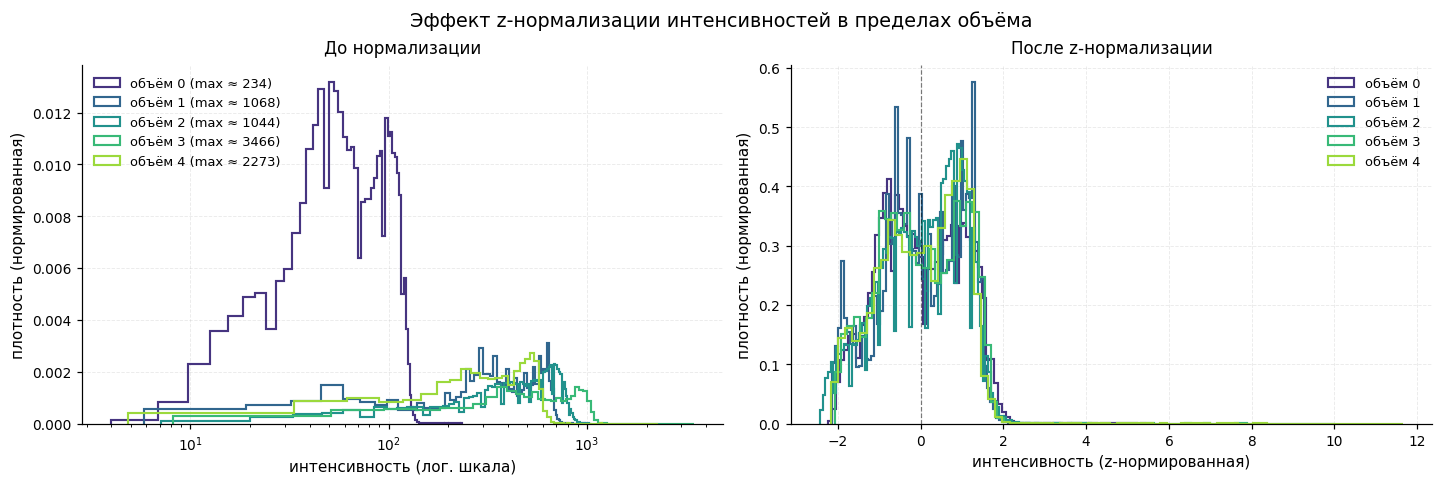

In [7]:
# Гистограммы интенсивностей до и после нормализации на двух панелях.
# Левая панель — исходные интенсивности с явно различающимися масштабами.
# Правая панель — нормализованные интенсивности, сошедшиеся к сопоставимым шкалам.

fig, ax = plt.subplots(1, 2, figsize=(13, 4.3), constrained_layout=True)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, N_EXAMPLES))

# Слева: исходные распределения (логарифмическая ось x для читаемости)
for i, (raw, c) in enumerate(zip(raw_intensities, colors)):
    ax[0].hist(raw, bins=80, histtype="step", color=c, linewidth=1.4,
               density=True, label=f"объём {i} (max ≈ {raw.max():.0f})")
ax[0].set_xscale("log")
ax[0].set_xlabel("интенсивность (лог. шкала)")
ax[0].set_ylabel("плотность (нормированная)")
ax[0].set_title("До нормализации")
ax[0].legend(loc="upper left", fontsize=8.5)

# Справа: нормализованные распределения
for i, (norm, c) in enumerate(zip(norm_intensities, colors)):
    ax[1].hist(norm, bins=80, histtype="step", color=c, linewidth=1.4,
               density=True, label=f"объём {i}")
ax[1].axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax[1].set_xlabel("интенсивность (z-нормированная)")
ax[1].set_ylabel("плотность (нормированная)")
ax[1].set_title("После z-нормализации")
ax[1].legend(loc="upper right", fontsize=8.5)

fig.suptitle("Эффект z-нормализации интенсивностей в пределах объёма")
plt.show()


**Выводы.** Сопоставление распределений до и после нормализации демонстрирует ожидаемый
эффект: исходные распределения, расположенные в различных интервалах интенсивностей и
различающиеся по масштабу на порядки, после нормализации сходятся в единую центрированную
шкалу с близкими формами. Средние интенсивностей нормализованных объёмов близки к нулю
(порядка единиц тысячных), стандартные отклонения — порядка единицы.

Этот результат подтверждает корректность реализации `NormalizeIntensityd` с параметром
`nonzero=True` и подтверждает выбор стратегии нормализации, обоснованный в разведочном
анализе данных (раздел 3 ноутбука 01). После нормализации входные данные модели имеют
сопоставимое распределение между исследованиями, что устраняет систематический сдвиг и
обеспечивает стабильность обучения.


### 4. Визуальный контроль препроцессинга

Серия аксиальных срезов через область разметки одного исследования отображается совместно
с разметкой. Визуальный контроль подтверждает сохранность пространственного соответствия
изображения и разметки после детерминированного препроцессинга: целевые структуры остаются
в анатомически корректном положении относительно подлежащей анатомии после приведения к
фиксированному размеру и нормализации интенсивностей.


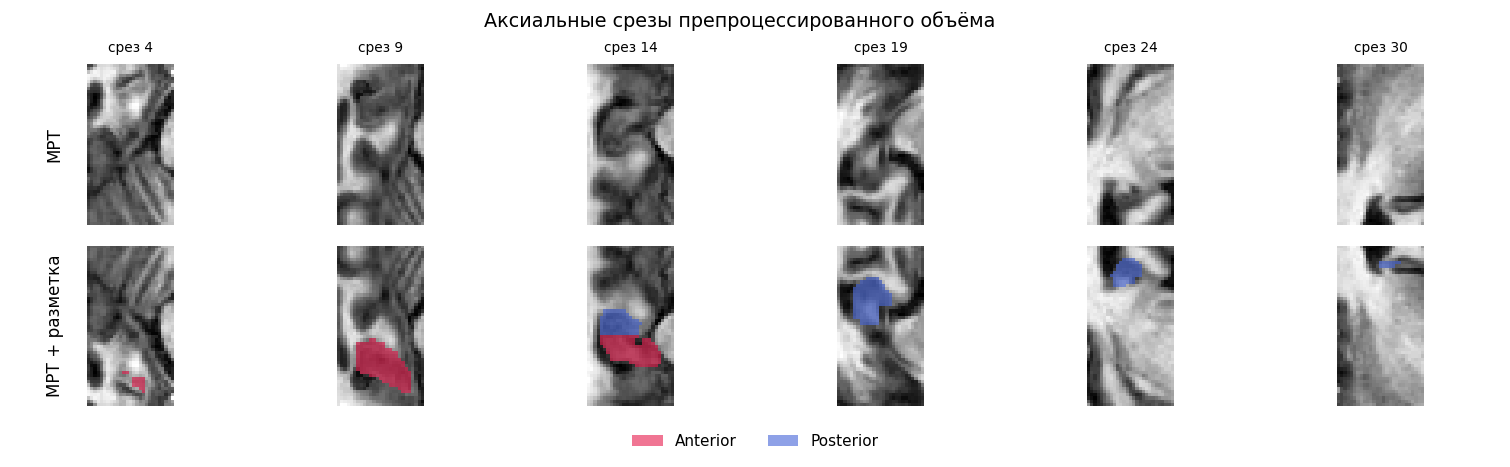

In [8]:
from matplotlib.gridspec import GridSpec
from src.visualization import (
    overlay_mask, pick_slices, class_legend_patches, annotate_rows, crop_to_bbox
)

img_np = sample["image"].numpy()[0]
lbl_np = sample["label"].numpy().astype(np.int16)[0]
img_np, lbl_np = crop_to_bbox(img_np, lbl_np, reference=lbl_np, margin=4)
slice_indices = pick_slices(lbl_np, 6)
n_slices = len(slice_indices)

# Раскладка: два ряда изображений + отдельный ряд под легенду.
# set_box_aspect форсирует соотношение сторон axes-box под форму отображаемого среза,
# что устраняет пустое пространство внутри axes (источник кажущегося наложения легенды).
fig = plt.figure(figsize=(2.4 * n_slices, 4.4))
gs = GridSpec(3, n_slices, height_ratios=[1, 1, 0.18],
              left=0.04, right=0.98, top=0.85, bottom=0.04,
              wspace=0.05, hspace=0.18, figure=fig)

row_top    = [fig.add_subplot(gs[0, j]) for j in range(n_slices)]
row_bottom = [fig.add_subplot(gs[1, j]) for j in range(n_slices)]
ax_legend  = fig.add_subplot(gs[2, :])
ax_legend.axis("off")

for j, s in enumerate(slice_indices):
    img2d = img_np[:, :, s].T
    h, w = img2d.shape
    row_top[j].imshow(img2d, cmap="gray", origin="lower")
    row_top[j].axis("off")
    row_top[j].set_box_aspect(h / w)
    row_top[j].set_title(f"срез {s}", fontsize=9)

    overlay_mask(row_bottom[j], img2d, lbl_np[:, :, s].T)
    row_bottom[j].set_box_aspect(h / w)

annotate_rows([row_top[0], row_bottom[0]], ["МРТ", "МРТ + разметка"])
ax_legend.legend(handles=class_legend_patches(), loc="center", ncol=2,
                 frameon=False, fontsize=10)
fig.suptitle("Аксиальные срезы препроцессированного объёма", y=0.96)
plt.show()


**Выводы.** Визуальный контроль подтверждает корректность препроцессинга: разметка точно
соответствует подлежащей анатомии гиппокампа на каждом срезе, форма границ структуры
сохранена, подобласти Anterior и Posterior разделены анатомически осмысленно. Приведение
к фиксированному размеру 48×64×48 не нарушило пространственного соответствия пары
«изображение–разметка». Нормализация интенсивностей сохранила контрастные соотношения
между тканями, необходимые для визуальной интерпретации.


### 5. Эффект стохастической аугментации

Обучающие трансформации, включающие стохастическую аугментацию, многократно применяются
к одному и тому же исходному объёму. Различие реализаций демонстрирует диапазон вариаций,
привносимых аугментацией, и подтверждает их работоспособность. Анализ выполняется на
аксиальном срезе через центр массы разметки — таким образом одна и та же анатомическая
плоскость показывается на оригинале и реализациях, и эффект преобразований становится
зрительно сопоставимым.


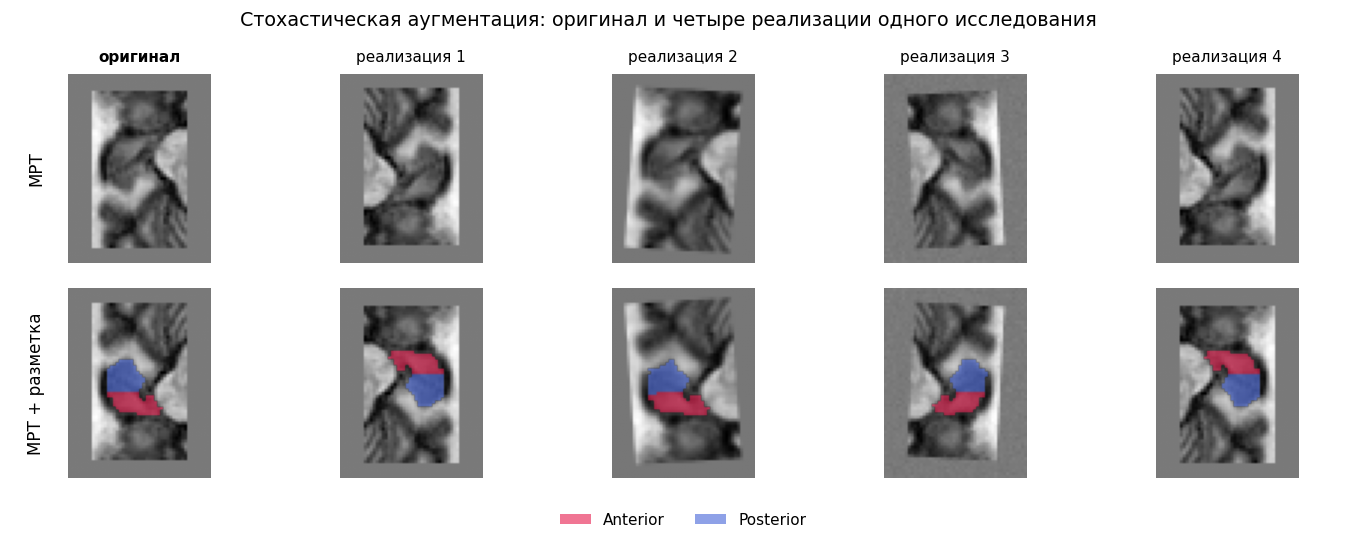

Состав стохастической аугментации обучающего конвейера:
  • RandFlipd по оси 0 (сагиттальной),  вероятность 0.5
  • RandFlipd по оси 1 (коронарной),    вероятность 0.5
  • RandAffined: повороты ±0.1 рад, масштаб ±10 %, вероятность 0.3
  • RandGaussianNoised: σ = 0.05, вероятность 0.2


In [9]:
# Многократное применение обучающего конвейера к одному файлу.
# Все реализации одного объёма наряду с детерминированным оригиналом
# отображаются на одном рисунке, на согласованной по центру масс плоскости.

train_tf = data_module.get_train_transforms(cfg)

N_AUG = 4
orig_sample = val_tf(train_files[0])
orig_img = orig_sample["image"].numpy()[0]
orig_lbl = orig_sample["label"].numpy().astype(np.int16)[0]

# Аксиальный срез через центр масс разметки оригинала
coords = np.array(np.nonzero(orig_lbl > 0))
mid_z = int(np.round(coords[2].mean()))

aug_samples = [train_tf(train_files[0]) for _ in range(N_AUG)]

# Раскладка с отдельным axes-row под легенду
n_cols = N_AUG + 1
fig = plt.figure(figsize=(2.6 * n_cols, 5.2))
gs = GridSpec(3, n_cols, height_ratios=[1, 1, 0.18],
              left=0.04, right=0.98, top=0.85, bottom=0.04,
              wspace=0.06, hspace=0.18, figure=fig)
row_top    = [fig.add_subplot(gs[0, j]) for j in range(n_cols)]
row_bottom = [fig.add_subplot(gs[1, j]) for j in range(n_cols)]
ax_legend  = fig.add_subplot(gs[2, :])
ax_legend.axis("off")


def _show_panel(ax_img, ax_overlay, img3d, lbl3d, z):
    img2d = img3d[:, :, z].T
    h, w = img2d.shape
    ax_img.imshow(img2d, cmap="gray", origin="lower")
    ax_img.axis("off"); ax_img.set_box_aspect(h / w)
    overlay_mask(ax_overlay, img2d, lbl3d[:, :, z].T)
    ax_overlay.set_box_aspect(h / w)


# Колонка 0: оригинал (детерминированный препроцессинг)
_show_panel(row_top[0], row_bottom[0], orig_img, orig_lbl, mid_z)
row_top[0].set_title("оригинал", fontsize=10, fontweight="bold")

# Колонки 1..N: реализации аугментации
for j, s in enumerate(aug_samples):
    aug_img = s["image"].numpy()[0]
    aug_lbl = s["label"].numpy().astype(np.int16)[0]
    coords_a = np.array(np.nonzero(aug_lbl > 0))
    z_aug = int(np.round(coords_a[2].mean())) if coords_a.size else mid_z
    _show_panel(row_top[j + 1], row_bottom[j + 1], aug_img, aug_lbl, z_aug)
    row_top[j + 1].set_title(f"реализация {j + 1}", fontsize=10)

annotate_rows([row_top[0], row_bottom[0]], ["МРТ", "МРТ + разметка"])
ax_legend.legend(handles=class_legend_patches(), loc="center", ncol=2,
                 frameon=False, fontsize=10)
fig.suptitle("Стохастическая аугментация: оригинал и четыре реализации одного исследования",
             y=0.96)
plt.show()

# Численная сводка трансформаций
print("Состав стохастической аугментации обучающего конвейера:")
print("  • RandFlipd по оси 0 (сагиттальной),  вероятность 0.5")
print("  • RandFlipd по оси 1 (коронарной),    вероятность 0.5")
print("  • RandAffined: повороты ±0.1 рад, масштаб ±10 %, вероятность 0.3")
print("  • RandGaussianNoised: σ = 0.05, вероятность 0.2")


**Выводы.** Многократное применение обучающих трансформаций к одному исследованию даёт
визуально различающиеся реализации, что подтверждает действие стохастической аугментации.
Различные реализации демонстрируют отражения по осям, повороты, незначительные
масштабирования и вариации интенсивностей, привносимые аддитивным шумом. Разметка
синхронно преобразуется вместе с изображением и сохраняет анатомическую согласованность.

Все наблюдаемые вариации остаются в пределах анатомически правдоподобных преобразований,
не порождая нереалистичных деформаций. Параметры аугментации (вероятности и амплитуды)
подобраны консервативно для предотвращения генерации клинически невозможных
конфигураций. Расширение эффективного разнообразия обучающих данных за счёт аугментации
служит средством снижения переобучения, что особенно существенно при ограниченном объёме
обучающей выборки (208 исследований).


### 6. Структура батча и характеристики загрузчиков

Загрузчики обучающей и валидационной подвыборок формируются с кэширующим набором данных
(`CacheDataset` с `cache_rate=1.0`). Однократная загрузка набора предваряет итерации:
результат детерминированного препроцессинга всех 208 обучающих и 52 валидационных
исследований удерживается в оперативной памяти. Последующие эпохи обучения не требуют
повторного чтения и применения детерминированных трансформаций; стохастическая
аугментация применяется поверх кэшированных результатов в момент обращения к элементу.

Раздел проверяет структуру батчей, формируемых загрузчиками: формы, типы данных и
характеристики, существенные для подачи на вход модели.


In [10]:
train_loader, val_loader = data_module.build_dataloaders(cfg)

batch = next(iter(train_loader))
img_b, lbl_b = batch["image"], batch["label"]

expected_batch_shape = (cfg.batch_size, cfg.num_input_channels, *cfg.spatial_size)
assert tuple(img_b.shape) == expected_batch_shape, "Несоответствие формы батча"

# Распределение классов в батче
flat_labels = lbl_b.numpy().ravel()
total = flat_labels.size
class_counts = {k: int(np.sum(flat_labels == k)) for k in cfg.labels}

print(f"Форма батча изображений     : {tuple(img_b.shape)}")
print(f"Форма батча разметки        : {tuple(lbl_b.shape)}")
print(f"Тип изображений             : {img_b.dtype}")
print(f"Тип разметки                : {lbl_b.dtype}")
print(f"Размер устройства           : {img_b.device}")
print()
print(f"Число батчей в обучающем загрузчике     : {len(train_loader)}")
print(f"Число батчей в валидационном загрузчике : {len(val_loader)}")
print()
print(f"Статистики интенсивностей батча:")
print(f"  min   : {img_b.min():+.3f}")
print(f"  max   : {img_b.max():+.3f}")
print(f"  mean  : {img_b.mean():+.3f}")
print(f"  std   : {img_b.std():+.3f}")
print()
print(f"Распределение классов в батче:")
for k, name in cfg.labels.items():
    pct = 100 * class_counts[k] / total
    print(f"  {name:12s} ({k}) : {class_counts[k]:>9,} вокселей  ({pct:5.2f} %)")


Loading dataset: 100%|██████████| 52/52 [00:38<00:00,  1.37it/s]


Форма батча изображений     : (4, 1, 48, 64, 48)
Форма батча разметки        : (4, 1, 48, 64, 48)
Тип изображений             : torch.float32
Тип разметки                : torch.float32
Размер устройства           : cpu

Число батчей в обучающем загрузчике     : 52
Число батчей в валидационном загрузчике : 13

Статистики интенсивностей батча:
  min   : -2.395
  max   : +11.631
  mean  : +0.000
  std   : +0.650

Распределение классов в батче:
  background   (0) :   576,218 вокселей  (97.69 %)
  Anterior     (1) :     7,094 вокселей  ( 1.20 %)
  Posterior    (2) :     6,512 вокселей  ( 1.10 %)


**Выводы.** Загрузчик формирует батчи требуемой структуры: тензоры формы
`(4, 1, 48, 64, 48)`, соответствующей размеру батча, числу входных каналов и
пространственному размеру, с типом данных `float32`. Обучающая подвыборка организована в
52 батча по 4 элемента, валидационная — в 13 батчей; число батчей согласовано с размерами
подвыборок и заданным размером батча.

Статистики интенсивностей подтверждают сохранность нормализации после батчевания: среднее
близко к нулю, стандартное отклонение порядка единицы — близко к ожидаемому значению с
учётом наличия фоновых вокселей с нулевыми значениями.

Доля переднего плана в батче (≈ 2.3 %, фон ≈ 97.7 %) **меньше** доли, установленной в
разведочном анализе данных по исходным маскам (5.25 % переднего плана, 94.75 % фона).
Это снижение является ожидаемым следствием приведения томограмм к фиксированному
пространственному размеру 48×64×48: исходный объём томограммы (порядка 35×50×36 ≈ 63 тыс.
вокселей) увеличивается приблизительно в 2.3 раза до 48×64×48 = 147 456 вокселей, причём
добавляемые вокселы относятся к фоновому классу. Иными словами, после приведения к размеру
структура целевых классов сохранена, а изменение долей объясняется добавлением фоновых
вокселей при дополнении по краям. Этот эффект учитывается при интерпретации последующих
метрик, агрегированных по объёму.


## Обсуждение и переход к следующему этапу

### Сводка верификации

| Этап конвейера | Проектное решение | Результат верификации |
|---|---|---|
| Чтение перечня | Источник — `dataset.json` поля `training` | 260 пар «изображение–разметка», корректное соответствие |
| Разбиение | Случайное, доля 0.2, фиксированный seed | 208 / 52, подвыборки не пересекаются |
| Загрузка | `LoadImaged` для NIfTI | Корректное чтение пар |
| Каналы | `EnsureChannelFirstd` | Форма `(1, X, Y, Z)` |
| Ориентация | `Orientationd(RAS)` | Унификация осей |
| Нормализация интенсивностей | `NormalizeIntensityd(nonzero=True)` | Сходимость распределений: mean ≈ 0, std ≈ 1 |
| Приведение к размеру | `ResizeWithPadOrCropd(48, 64, 48)` | Целевая форма достигнута без искажения разметки |
| Сохранность классов | Интерполяция nearest для разметки | Все три класса присутствуют после препроцессинга |
| Аугментация | `RandFlipd`, `RandAffined`, `RandGaussianNoised` | Анатомически правдоподобные вариации |
| Кэширование | `CacheDataset(cache_rate=1.0)` | Полное кэширование, повторное чтение исключено |
| Батч | `DataLoader(batch_size=4)` | Форма `(4, 1, 48, 64, 48)`, `float32` |

### Эмпирические следствия верификации

Помимо подтверждения корректности этапов конвейера, ноутбук установил ряд эмпирических
фактов, существенных для последующих этапов и **не следующих из разведочного анализа
напрямую**.

**Сходимость распределений после нормализации.** Разведочный анализ установил факт
расхождения масштабов интенсивностей между исследованиями; настоящий ноутбук **измеряет
эффект применённой нормализации** на тех же исследованиях: средние нормализованных
интенсивностей сосредоточены в окрестности нуля, стандартные отклонения порядка единицы,
формы распределений сопоставимы. Это эмпирически подтверждает, что выбранная стратегия
(`NormalizeIntensityd` с ограничением статистики ненулевыми вокселями) действительно
устраняет расхождение масштабов — что не было самоочевидным до применения.

**Сохранность дискретных меток разметки при ресайзинге.** Приведение к фиксированному
пространственному размеру операцией дополнения и обрезания по краям, в сочетании с
интерполяцией методом ближайшего соседа для разметки, не привело к утрате классов
переднего плана или искажению дискретности меток ни в одном проверенном случае.

**Анатомическая правдоподобность аугментаций.** Визуальный контроль реализаций
стохастической аугментации обучающего конвейера подтверждает, что выбранные параметры
(вероятности 0.5 / 0.3 / 0.2 для отражений / аффинных / шума, амплитуды поворотов в
0.1 рад и масштабирования в 10 %) дают вариации в пределах анатомически допустимых
преобразований и не порождают клинически невозможных конфигураций. Это качественное
наблюдение, недоступное априорному обоснованию.

**Осуществимость полного кэширования.** `CacheDataset` с `cache_rate=1.0` успешно
удерживает все 260 размеченных объёмов после препроцессинга в оперативной памяти при
параметрах среды Colab. Однократная загрузка занимает порядка нескольких минут; в цикле
обучения повторное чтение и применение детерминированных трансформаций исключается, что
существенно сокращает время эпохи.

**Сдвиг распределения классов вследствие приведения к размеру.** Доля переднего плана в
батче (≈ 2.3 %) меньше доли, установленной разведочным анализом по исходным маскам
(5.25 %). Снижение является ожидаемым следствием приведения к фиксированному размеру
48×64×48: добавляемые при дополнении вокселы относятся к фоновому классу и увеличивают
суммарный объём фона приблизительно в 2.3 раза без изменения объёма целевых структур.
Этот эффект существенен при интерпретации метрик, агрегированных по объёму, и при выборе
функции потерь — он усиливает требование к её устойчивости относительно дисбаланса классов
(удовлетворяется компонентой Dice в комбинированной функции потерь Dice + Cross-Entropy).

### Подготовка к следующему этапу

Сформированный конвейер подготавливает данные в форме, пригодной для подачи на вход
трёхмерной сегментационной модели: тензоры размерности `(B, 1, 48, 64, 48)` для изображений
и `(B, 1, 48, 64, 48)` индексов классов для разметки. Это образует основу для определения
архитектуры модели, функции потерь и метрик качества — содержания следующего ноутбука.
